In [3]:
import io
import functools

import numpy as np

import soundfile
import matplotlib
import matplotlib.pylab as plt
from IPython.display import display, Audio

from einops import rearrange

from nara_wpe.utils import stft, istft


from pb_bss.distribution import CACGMMTrainer
from pb_bss.permutation_alignment import DHTVPermutationAlignment, OraclePermutationAlignment


c:\Données\Cours\IMTA\2a\SLSR\projet git\Blind-source-detection\code\cagcmm\pb_bss\extraction\beamformer.py:42: UserWarning: Could not import cythonized get_gev_vector. Falling back to Python implementation. Maybe you need to rebuild/reinstall the toolbox?
  warnings.warn('Could not import cythonized get_gev_vector. Falling back '
c:\Données\Cours\IMTA\2a\SLSR\projet git\Blind-source-detection\code\cagcmm\pb_bss\extraction\beamformer.py:52: UserWarning: Could not import cythonized eig. Falling back to python implementation. Maybe you need to rebuild/reinstall the toolbox?
  warnings.warn('Could not import cythonized eig. Falling back to '


In [4]:
def string_function(a):
    if a.size < 50:
        return str(a)
    else:
        return f'array(shape={a.shape}, dtype={a.dtype})'
np.set_printoptions(formatter={'all': lambda x: string_function(x)})


# Read some data
You can use `soundfile.read` directly, when reading local files.

Read the observation $\mathbf y_n$ and the source images $\mathbf x_{0, n}$ and $\mathbf x_{1, n}$ and the noise $\mathbf n_n$
$$
\mathbf{y}_n = \mathbf x_{0, n} + \mathbf x_{1, n} + \mathbf n_{n} \in \mathbb R ^ D
$$

In [5]:
from urllib.request import urlopen

sample_rate = 8000

@functools.lru_cache()
def soundfile_read(url):
    data, data_sample_rate = soundfile.read(io.BytesIO(urlopen(url).read()))
    
    assert sample_rate == data_sample_rate, (sample_rate, data_sample_rate)
    
    print(f'Read: {url}.\nSample rate: {data_sample_rate}')
    return np.ascontiguousarray(data.T)



In [6]:

observation = soundfile_read(
    "https://github.com/fgnt/pb_test_data/raw/master/bss_data/low_reverberation/observation.wav"
)
speech_image_0 = soundfile_read(
    "https://github.com/fgnt/pb_test_data/raw/master/bss_data/low_reverberation/speech_image_0.wav"
)
speech_image_1 = soundfile_read(
    "https://github.com/fgnt/pb_test_data/raw/master/bss_data/low_reverberation/speech_image_1.wav"
)
speech_image = np.array([speech_image_0, speech_image_1])
noise_image = soundfile_read(
    "https://github.com/fgnt/pb_test_data/raw/master/bss_data/low_reverberation/noise_image.wav"
)
speech_source_0 = soundfile_read(
    "https://github.com/fgnt/pb_test_data/raw/master/bss_data/low_reverberation/speech_source_0.wav"
)
speech_source_1 = soundfile_read(
    "https://github.com/fgnt/pb_test_data/raw/master/bss_data/low_reverberation/speech_source_1.wav"
)
speech_source = np.array([speech_source_0, speech_source_1])

observation, speech_image, noise_image, speech_source

Read: https://github.com/fgnt/pb_test_data/raw/master/bss_data/low_reverberation/observation.wav.
Sample rate: 8000
Read: https://github.com/fgnt/pb_test_data/raw/master/bss_data/low_reverberation/speech_image_0.wav.
Sample rate: 8000
Read: https://github.com/fgnt/pb_test_data/raw/master/bss_data/low_reverberation/speech_image_1.wav.
Sample rate: 8000
Read: https://github.com/fgnt/pb_test_data/raw/master/bss_data/low_reverberation/noise_image.wav.
Sample rate: 8000
Read: https://github.com/fgnt/pb_test_data/raw/master/bss_data/low_reverberation/speech_source_0.wav.
Sample rate: 8000
Read: https://github.com/fgnt/pb_test_data/raw/master/bss_data/low_reverberation/speech_source_1.wav.
Sample rate: 8000


(array([[0.009538459591567516, 0.01817665994167328, 0.1117701604962349,
         ..., -0.07111404091119766, 0.1369105875492096,
         -0.11973387002944946],
        [0.018182551488280296, -0.020255137234926224, -0.0321602001786232,
         ..., -0.07328560948371887, 0.09082978218793869,
         -0.04740132391452789],
        [0.014930974692106247, 0.068822480738163, 0.04527219384908676,
         ..., -0.052641719579696655, 0.17078129947185516,
         -0.09765646606683731],
        [-0.022554872557520866, -0.05830945819616318, 0.03208436816930771,
         ..., -0.01762104034423828, 0.16667617857456207,
         -0.1149032711982727],
        [-0.023966457694768906, 0.05308924615383148,
         -0.015626665204763412, ..., -0.001825682818889618,
         -0.006927268113940954, -0.10825322568416595],
        [0.0129325482994318, 0.001461072824895382, 0.07945423573255539,
         ..., -0.0594734363257885, 0.09246037155389786,
         -0.05176294967532158]]),
 array([[[8.8106804469

In [7]:
def plot_mask(mask, *, ax=None):
    if ax is None:
        ax = plt.gca()
    image = ax.imshow(
        mask,
        interpolation='nearest',
        vmin=0,
        vmax=1,
        origin='lower'
    )
    cbar = plt.colorbar(image, ax=ax)
    return ax

def plot_stft(stft_signal, *, ax=None):
    if ax is None:
        ax = plt.gca()
        
    stft_signal = np.abs(stft_signal)
        
    
    stft_signal = 10 * np.log10(
        np.maximum(stft_signal, np.max(stft_signal) / 1e6))
    # 1e6: 60 dB is sufficient
        
    image = ax.imshow(
        stft_signal,
        interpolation='nearest',
        origin='lower',
    )
    cbar = plt.colorbar(image, ax=ax)
    cbar.set_label('Energy / dB')
    return ax

# Calculate the STFT signals
When the first letter is uppercase, this indicates a STFT signal

In [8]:
Observation = stft(observation, 512, 128)
Speech_image = stft(speech_image, 512, 128)
Noise_image = stft(noise_image, 512, 128)
Observation, Speech_image, Noise_image

(array([[[(0.03381023824580454+0j),
          (-0.018976682722945136+0.03693422000450787j),
          (-0.04861520234437615-0.038183507111176095j), ...,
          (0.010075699847193958-0.009150551614080467j),
          (0.008816542262090362+0.0001484188387136827j),
          (0.004885482143914826+0j)],
         [(-0.02828754455115412+0j),
          (-0.03531150568401949-0.09904434942609563j),
          (0.026175161293711696+0.10908637490136186j), ...,
          (-0.317167809605193+0.20829940197060703j),
          (-0.10042115070698938-0.4002452652258714j),
          (0.4223348122590459+0j)],
         [(-0.4561878252077103+0j),
          (0.2883817516906971-0.26204605950032284j),
          (0.029015137418630682+0.26397045874507846j), ...,
          (0.4928257539353379-0.11426612560011619j),
          (-0.9447999462453778-0.12282576325277793j),
          (1.1994780858102263+0j)],
         ...,
         [(0.9214504891323565+0j),
          (-1.076721313028036-0.20057721134162676j),
       

<Axes: >

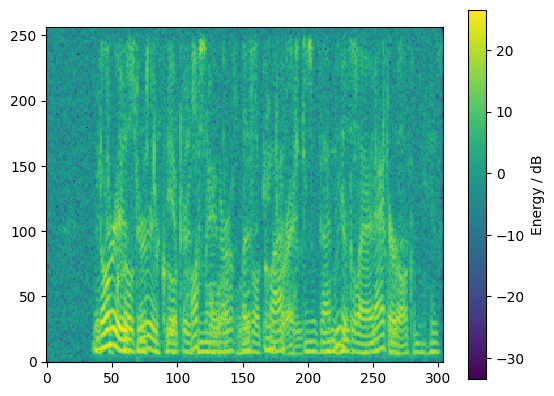

In [9]:
plot_stft(Observation[0].T)

# Train a mixture model on each frequency

- Instantiate a Trainer 
  - In our experiments most of the time the cACGMM yields the best results
  - The Trainer ist statefull, becasue some distributione (e.g. complex Watson) instantiate a numeric solver
- Call the fit function. There are three way to start the EM algorithm:
  - initialization: np.array with shape (..., K, N)
     - An affiliation mask, that indicate the initial probabilities.
  - num_classes: Scalar
     - Calculates an i.i.d. initialization mask and falls back to the case above
  - initialization: Probabilty instance (i.e. The returned model of the fit function) (e.g. CACGMM instance) 
     - Provide a trained model.
  - Call predict on the trained model to obtain the affiliation (i.e. posterior)

In [10]:
trainer = CACGMMTrainer()
#trainer = CWMMTrainer()
# trainer = CBMMTrainer()

In [ ]:
Observation_mm = rearrange(Observation, 'd t f -> f t d')

model = trainer.fit(
    Observation_mm,
    num_classes=3,
    iterations=40,
    inline_permutation_aligner=None
)
model

In [ ]:
affiliation = model.predict(Observation_mm)
affiliation

array([[[0.00050695670719604, 7.047215498654929e-06, 0.9326322231543347,
         ..., 0.8540162944044342, 0.056047376963833696,
         0.00010535368160609026],
        [0.9732037743157486, 0.0044120440402637085,
         0.006296849515312955, ..., 0.13720194027861524,
         0.39623010428301025, 4.18747434987263e-05],
        [0.026289268977055327, 0.9955809087442378, 0.06107092733035237,
         ..., 0.008781765316950688, 0.5477225187531559,
         0.9998527715748952]],

       [[0.9662595651105199, 0.9821249935552501, 0.6978703229046999,
         ..., 0.00441486319620632, 0.01287621244939433,
         0.21341639354630262],
        [0.030960641852364374, 0.012198157577592263,
         0.03929168792718831, ..., 0.9586173158332373,
         0.4675725542194068, 0.09336263588040537],
        [0.002779793037115571, 0.005676848867157811,
         0.26283798916811185, ..., 0.03696782097055635,
         0.5195512333311989, 0.6932209705732921]],

       [[0.16245698222235613, 0.0501287

# Permutation alignment
 - The model is trained for each frequeny independent. So the permutation between all frequencies is random. (See next plot)
 - Apply a permutation alignment between the frequencies that was originally implemented from Dang Hai Tran Vu.
 - Calculate the global permutation to identify the speakers and the noise (This uses oracle information)
   - Use as enhanced signal the observaton multiplied with the mask (ToDo: Move beamformer code to pb_bss and use beamforming instead of masking)

<Axes: >

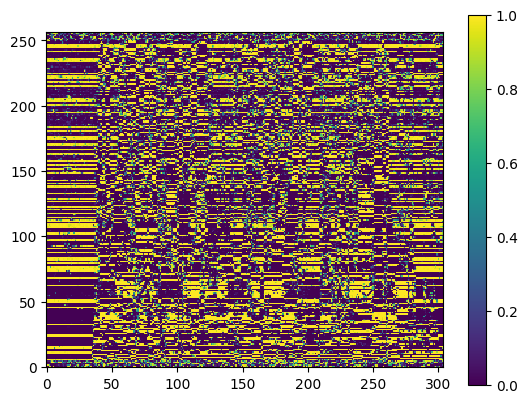

In [ ]:
plot_mask(affiliation[:, 0, :])

In [ ]:
pa = DHTVPermutationAlignment.from_stft_size(512)

In [ ]:

mapping = pa.calculate_mapping(
    rearrange(affiliation, 'f k t -> k f t')
)
affiliation_pa = pa.apply_mapping(
    rearrange(affiliation, 'f k t -> k f t'),
    mapping,
)

# Alternative to obtain affiliation_pa:
#     affiliation_pa = pa(rearrange(affiliation, 'f k t -> k f t'))

affiliation_pa

array([[[0.026289268977055327, 0.9955809087442378, 0.06107092733035237,
         ..., 0.008781765316950688, 0.5477225187531559,
         0.9998527715748952],
        [0.030960641852364374, 0.012198157577592263,
         0.03929168792718831, ..., 0.9586173158332373,
         0.4675725542194068, 0.09336263588040537],
        [0.8322212901409421, 0.9478382329951562, 0.2715719505113776,
         ..., 0.07019525278792575, 0.03896030974900032,
         0.07695604816945714],
        ...,
        [0.6654990979651786, 0.1634280562740958, 0.8023267651941016,
         ..., 0.036216814789676435, 0.016368661019736278,
         0.29986757173216316],
        [0.05678485925625945, 0.003299863947450433,
         0.0040087985754716105, ..., 0.07617031549913868,
         0.026862721648930058, 0.03707762185898194],
        [0.4627269566744017, 0.04253901196466762, 0.02084414744153988,
         ..., 0.0007148348197657837, 0.0003374059377559147,
         3.922347999716741e-05]],

       [[0.0005069567071960

In [ ]:
Observation, Speech_image, Noise_image

(array([[[(0.03381023824580454+0j),
          (-0.018976682722945136+0.03693422000450787j),
          (-0.04861520234437615-0.038183507111176095j), ...,
          (0.010075699847193958-0.009150551614080467j),
          (0.008816542262090362+0.0001484188387136827j),
          (0.004885482143914826+0j)],
         [(-0.02828754455115412+0j),
          (-0.03531150568401949-0.09904434942609563j),
          (0.026175161293711696+0.10908637490136186j), ...,
          (-0.317167809605193+0.20829940197060703j),
          (-0.10042115070698938-0.4002452652258714j),
          (0.4223348122590459+0j)],
         [(-0.4561878252077103+0j),
          (0.2883817516906971-0.26204605950032284j),
          (0.029015137418630682+0.26397045874507846j), ...,
          (0.4928257539353379-0.11426612560011619j),
          (-0.9447999462453778-0.12282576325277793j),
          (1.1994780858102263+0j)],
         ...,
         [(0.9214504891323565+0j),
          (-1.076721313028036-0.20057721134162676j),
       

In [ ]:
global_pa_est = rearrange(affiliation_pa, 'k f (t d) -> k d t f', d=1) * rearrange(Observation, 'd t (f k) -> k d t f', k=1)
global_pa_est = rearrange(global_pa_est, 'k d t f -> k (d t f)')
global_pa_reference = rearrange(np.array([*Speech_image, Noise_image]), 'k d t f -> k (d t f)')
global_pa = OraclePermutationAlignment()
global_permutation = global_pa.calculate_mapping(global_pa_est, global_pa_reference)
global_permutation

affiliation_pa = affiliation_pa[global_permutation]
global_permutation

array([1, 2, 0])

# Visualize the output
 - Display the masks, the enhanced signals and the clean signals

<Axes: >

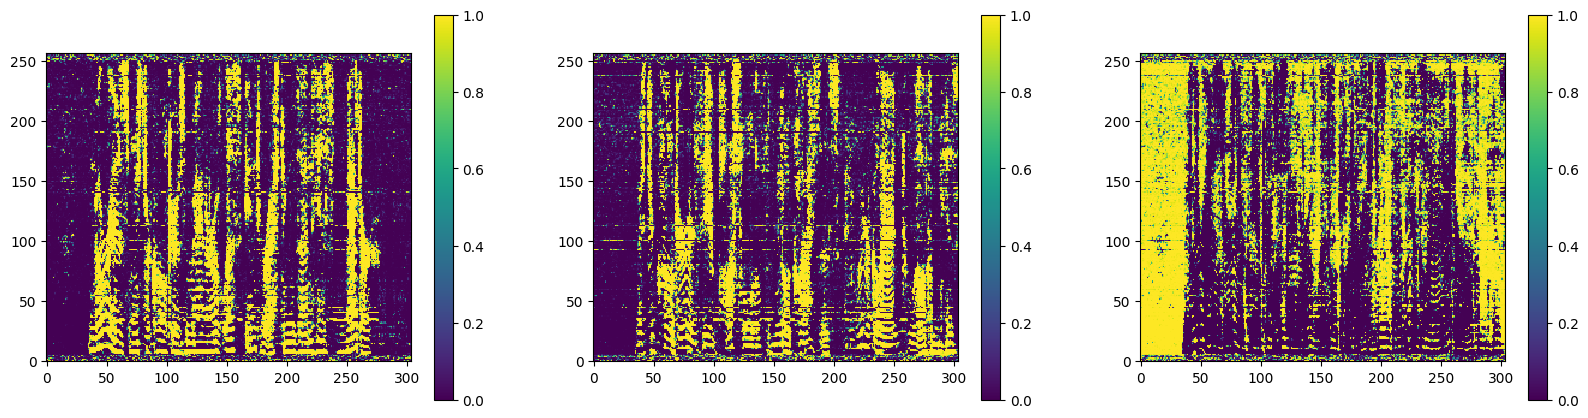

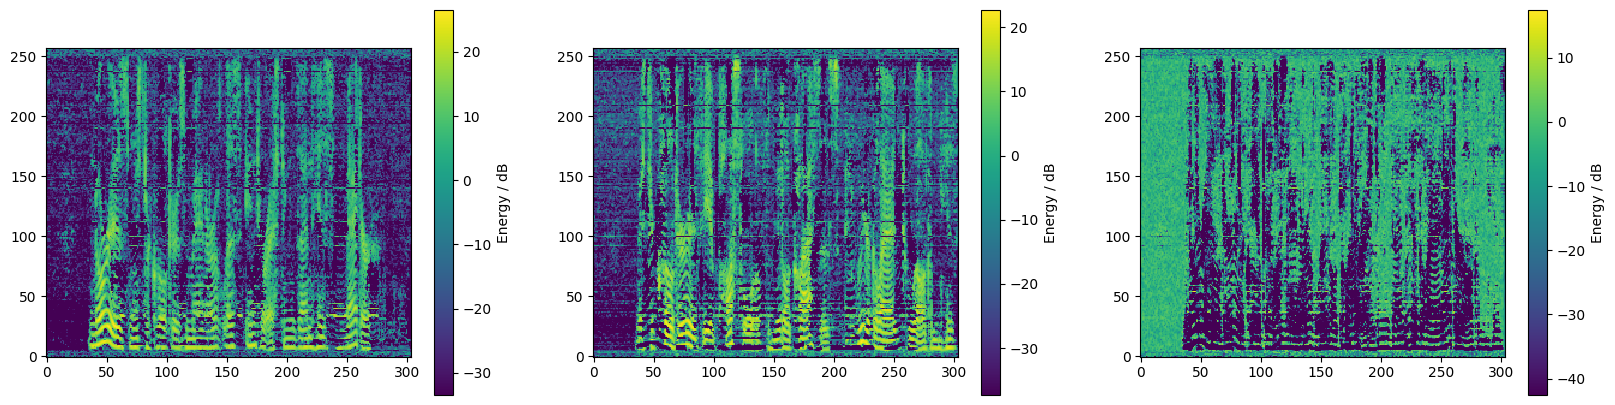

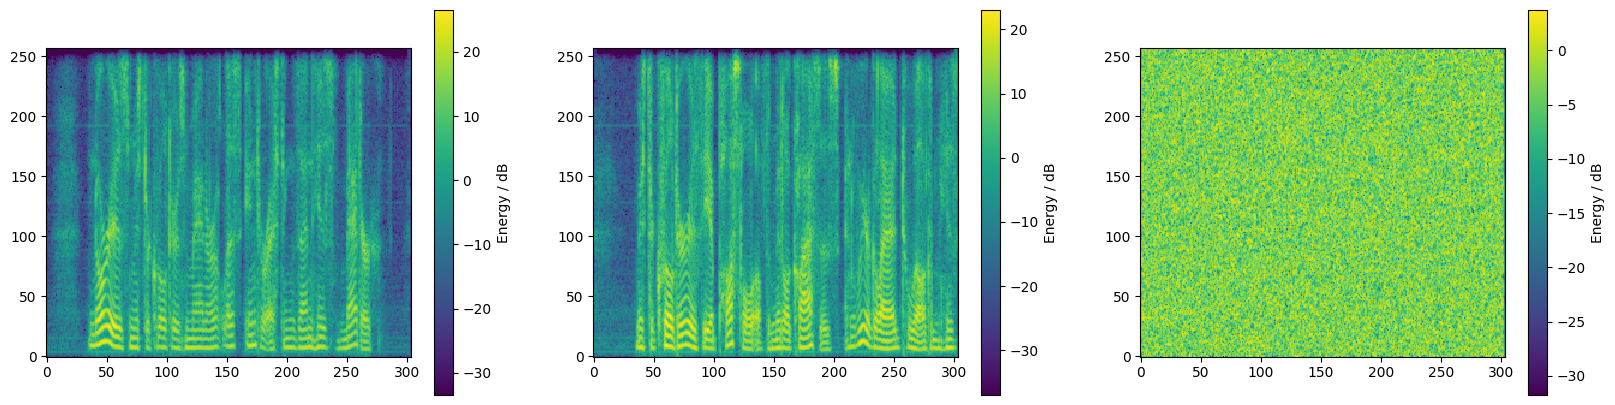

In [ ]:
reference_channel = 0

f, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(20, 5))

plot_mask(affiliation_pa[0, :, :], ax=ax0)
plot_mask(affiliation_pa[1, :, :], ax=ax1)
plot_mask(affiliation_pa[2, :, :], ax=ax2)

f, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(20, 5))

Speech_image_0_est = Observation[reference_channel, :, :].T * affiliation_pa[0, :, :]
Speech_image_1_est = Observation[reference_channel, :, :].T * affiliation_pa[1, :, :]
Noise_image_est = Observation[reference_channel, :, :].T * affiliation_pa[2, :, :]

plot_stft(Speech_image_0_est, ax=ax0)
plot_stft(Speech_image_1_est, ax=ax1)
plot_stft(Noise_image_est, ax=ax2)

f, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(20, 5))

plot_stft(Speech_image[0, reference_channel, :, :].T, ax=ax0)
plot_stft(Speech_image[1, reference_channel, :, :].T, ax=ax1)
plot_stft(Noise_image[reference_channel, :, :].T, ax=ax2)

In [ ]:
Speech_image_0_est

array([[(1.7140327050606688e-05+0j), (-1.993484223797851e-07+0j),
        (-0.4254554655994079+0j), ..., (0.7869337322059684+0j),
        (-0.003431765789614073+0j), (-1.2531573805823825e-05+0j)],
       [(-0.018336401195113285+0.03568804335925204j),
        (-0.034680312292343814-0.09727393104178811j),
        (0.20125306617220975-0.1828741681593945j), ...,
        (-0.004753577297458421-0.0008855209483498448j),
        (0.005713479595396089-0.0038824772241637597j),
        (-0.002043920674538665+0.026667059213758466j)],
       [(-0.0002587168658799147-0.00020320222505974396j),
        (5.321549572781046e-05+0.0002217784048161859j),
        (0.020218671901272717+0.18394302325682602j), ...,
        (1.1470199468337487+0.2386739938010233j),
        (-0.6838564866139901-0.051172314717135736j),
        (0.129915783684873+0.028283913328412465j)],
       ...,
       [(0.00011980310899602205-0.0001088028175730853j),
        (-0.00041838213421558897+0.0002747717319130691j),
        (0.0829178

In [ ]:
speech_image_0_est = istft(Speech_image_0_est.T, 512, 128)[..., :observation.shape[-1]]
speech_image_1_est = istft(Speech_image_1_est.T, 512, 128)[..., :observation.shape[-1]]
noise_image_est = istft(Noise_image_est.T, 512, 128)[..., :observation.shape[-1]]
speech_image_0_est, speech_image_1_est, noise_image_est

(array([0.003169108195414121, -0.003548671371837266, 0.0037826553717070716,
        ..., -0.0031051340228151056, -0.0032458399804921215,
        -0.003962483190086423]),
 array([-0.0011781965393046546, -0.0022964790742326232,
        1.8712051149863126e-05, ..., -0.08627359715798658,
        0.09030617879149955, -0.052579472566126946]),
 array([0.0075475479354580426, 0.024021810387743172, 0.10796879307337796,
        ..., 0.01826469026960405, 0.04985024873820218, -0.0631919142732361]))

In [ ]:
display(
    'speech_image_0_est',
    Audio(speech_image_0_est, rate=sample_rate),
    'speech_image_1_est',
    Audio(speech_image_1_est, rate=sample_rate),
)


'speech_image_0_est'

'speech_image_1_est'

## Analysis of the results

Tous les fichiers audio ont été normalisés et enregistrés dans le dossier 'output'.


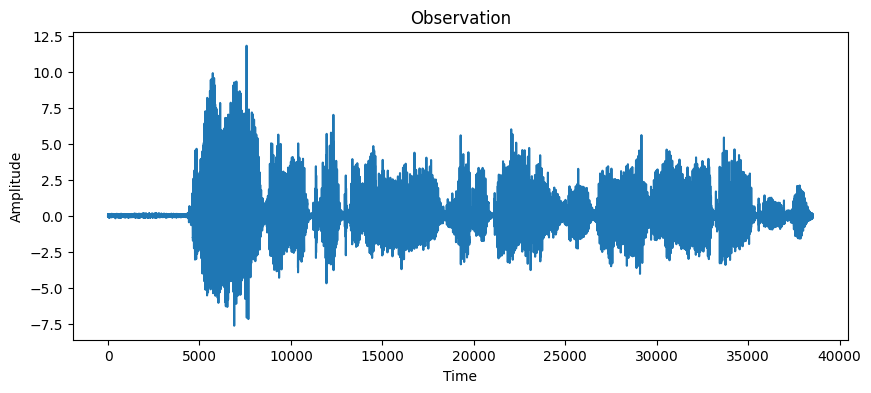

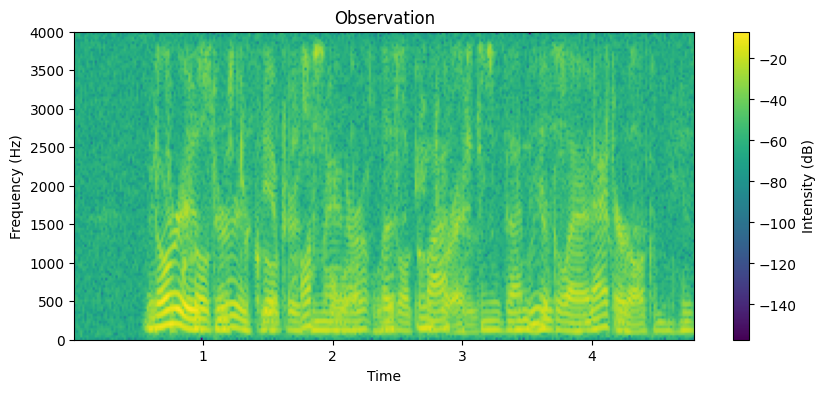

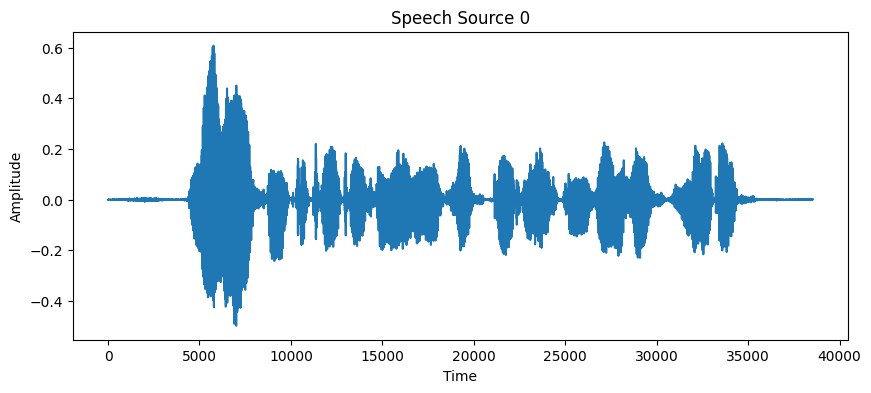

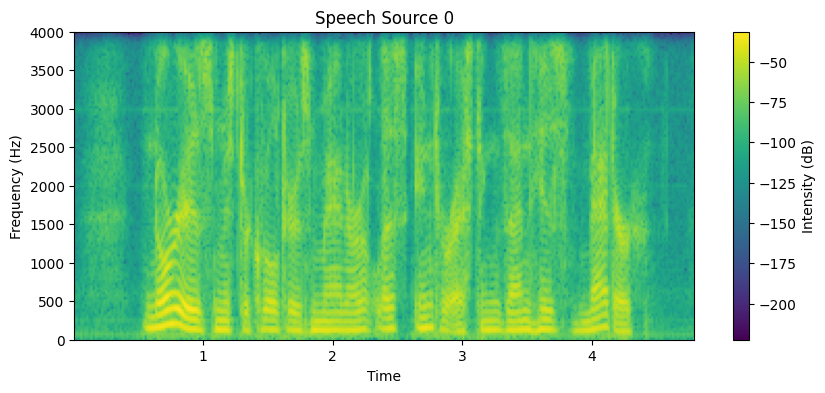

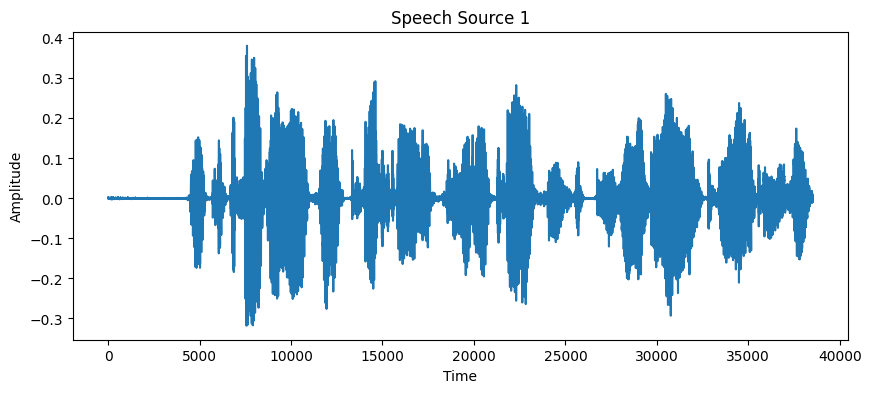

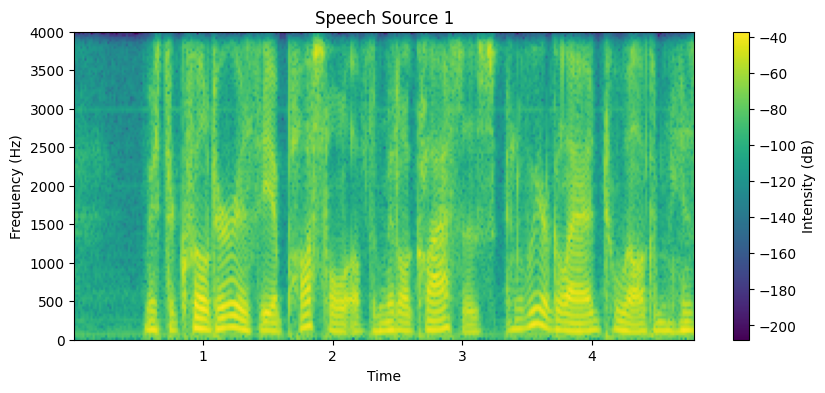

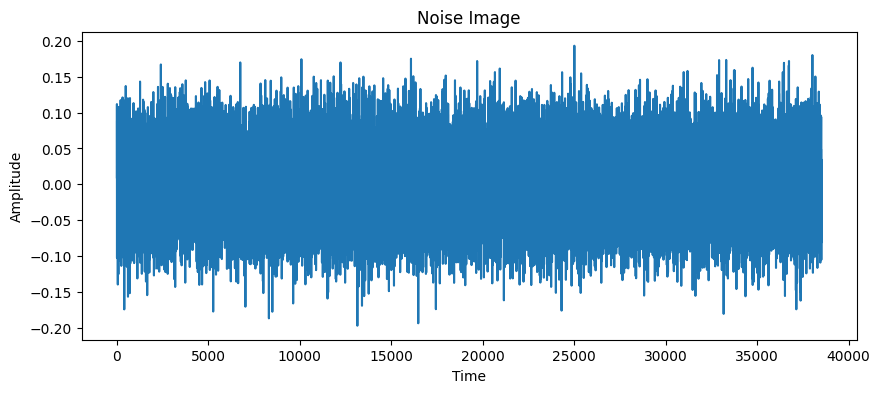

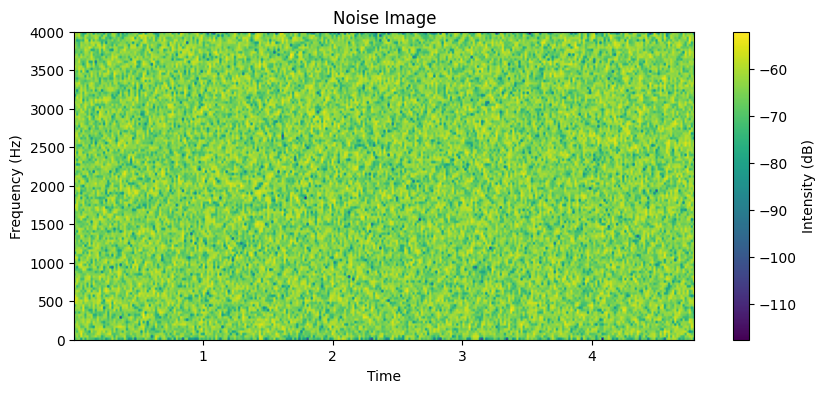

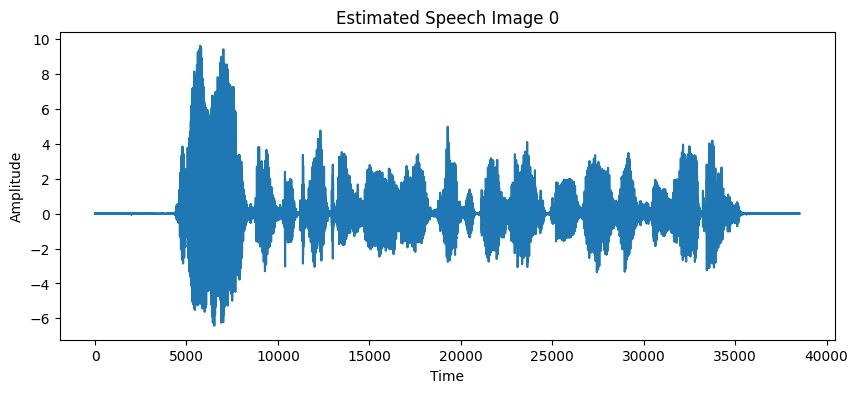

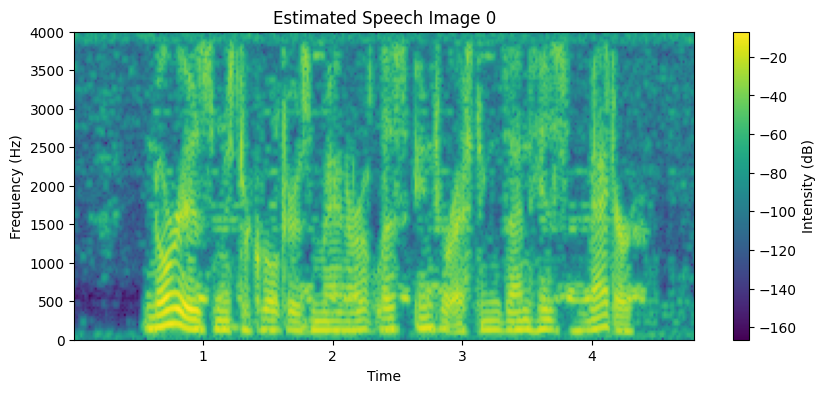

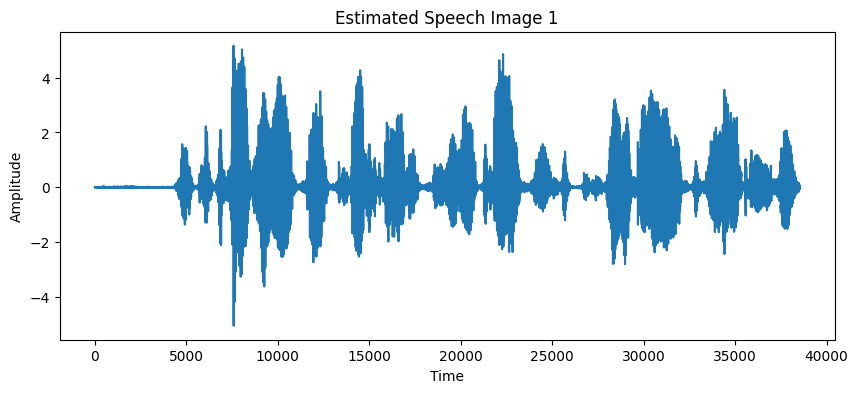

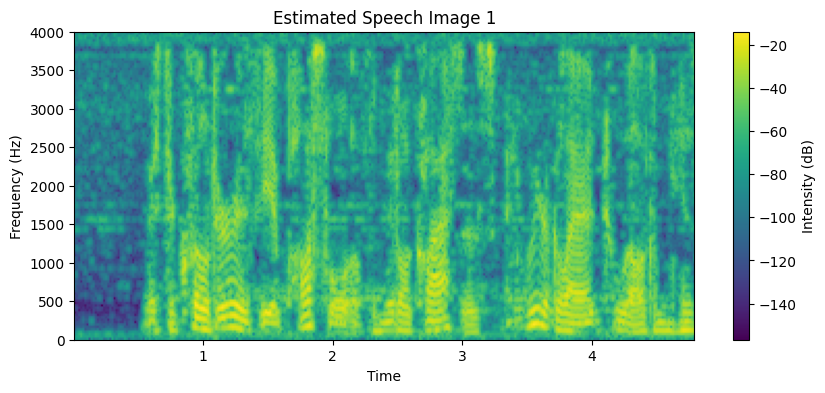

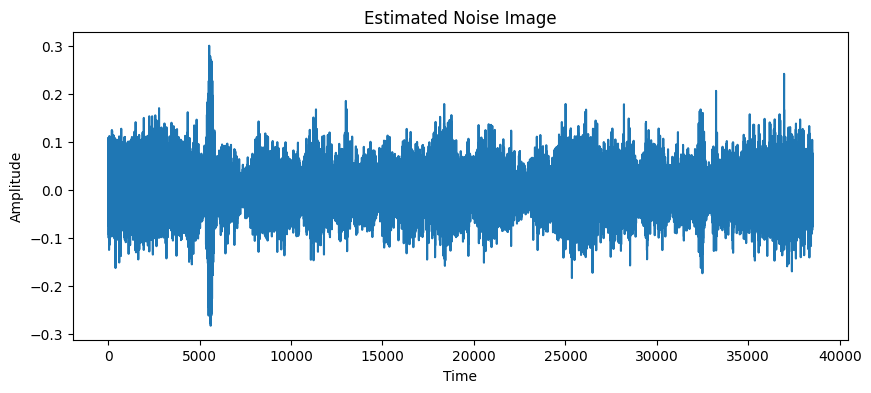

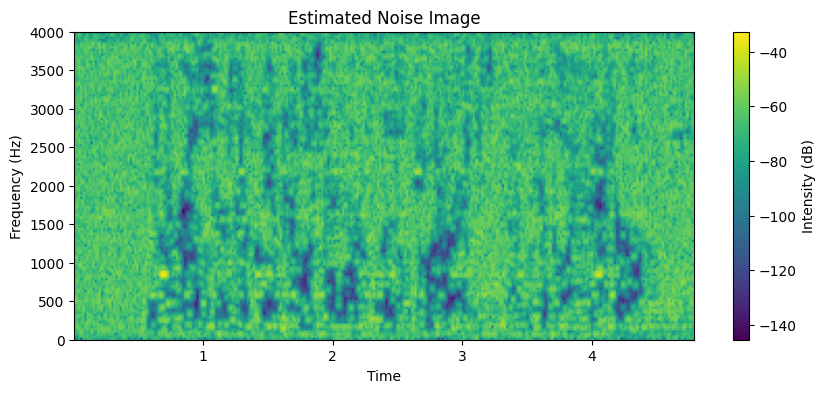

Observation:


Speech Source 0:


Speech Source 1:


Noise Image:


Estimated Speech Image 0:


Estimated Speech Image 1:


Estimated Noise Image:


In [ ]:
import os
import numpy as np
import soundfile
import matplotlib.pyplot as plt
from IPython.display import display, Audio

# Créer le dossier 'output' s'il n'existe pas
output_dir = 'output'
os.makedirs(output_dir, exist_ok=True)

# Fonction de normalisation
def normalize_audio(signal):
    return signal / np.max(np.abs(signal))

# Normalisation de tous les signaux
observation_normalized = normalize_audio(observation.T)
speech_source_0_normalized = normalize_audio(speech_source[0])
speech_source_1_normalized = normalize_audio(speech_source[1])
noise_image_normalized = normalize_audio(noise_image.T)
speech_image_0_est_normalized = normalize_audio(speech_image_0_est)
speech_image_1_est_normalized = normalize_audio(speech_image_1_est)
noise_image_est_normalized = normalize_audio(noise_image_est)

# Enregistrement des fichiers audio normalisés dans le dossier 'output'
soundfile.write(os.path.join(output_dir, 'observation.wav'), observation_normalized, sample_rate)
soundfile.write(os.path.join(output_dir, 'speech_source_0.wav'), speech_source_0_normalized, sample_rate)
soundfile.write(os.path.join(output_dir, 'speech_source_1.wav'), speech_source_1_normalized, sample_rate)
soundfile.write(os.path.join(output_dir, 'noise_image.wav'), noise_image_normalized, sample_rate)
soundfile.write(os.path.join(output_dir, 'speech_image_0_est.wav'), speech_image_0_est_normalized, sample_rate)
soundfile.write(os.path.join(output_dir, 'speech_image_1_est.wav'), speech_image_1_est_normalized, sample_rate)
soundfile.write(os.path.join(output_dir, 'noise_image_est.wav'), noise_image_est_normalized, sample_rate)

print("Tous les fichiers audio ont été normalisés et enregistrés dans le dossier 'output'.")

# Fonction pour afficher un signal temporel
def plot_signal(signal, title):
    plt.figure(figsize=(10, 4))
    plt.plot(signal)
    plt.title(title)
    plt.xlabel('Time')
    plt.ylabel('Amplitude')
    plt.show()

# Fonction pour afficher un spectrogramme
def plot_spectrogram(signal, title, sample_rate):
    plt.figure(figsize=(10, 4))
    plt.specgram(signal, Fs=sample_rate, cmap='viridis')
    plt.title(title)
    plt.xlabel('Time')
    plt.ylabel('Frequency (Hz)')
    plt.colorbar(label='Intensity (dB)')
    plt.show()

# Affichage des signaux temporels et des spectrogrammes
signals = [
    (observation.T, 'Observation'),
    (speech_source[0], 'Speech Source 0'),
    (speech_source[1], 'Speech Source 1'),
    (noise_image.T, 'Noise Image'),
    (speech_image_0_est, 'Estimated Speech Image 0'),
    (speech_image_1_est, 'Estimated Speech Image 1'),
    (noise_image_est, 'Estimated Noise Image')
]

for signal, title in signals:
    # Si le signal est multicanaux, on prend le premier canal
    if signal.ndim > 1:
        signal = signal[:, 0]  # Prendre le premier canal
    plot_signal(signal, title)  # Afficher le signal temporel
    plot_spectrogram(signal, title, sample_rate)  # Afficher le spectrogramme

# Affichage des fichiers audio dans Jupyter Notebook
print("Observation:")
display(Audio(os.path.join(output_dir, 'observation.wav'), rate=sample_rate))
print("Speech Source 0:")
display(Audio(os.path.join(output_dir, 'speech_source_0.wav'), rate=sample_rate))
print("Speech Source 1:")
display(Audio(os.path.join(output_dir, 'speech_source_1.wav'), rate=sample_rate))
print("Noise Image:")
display(Audio(os.path.join(output_dir, 'noise_image.wav'), rate=sample_rate))
print("Estimated Speech Image 0:")
display(Audio(os.path.join(output_dir, 'speech_image_0_est.wav'), rate=sample_rate))
print("Estimated Speech Image 1:")
display(Audio(os.path.join(output_dir, 'speech_image_1_est.wav'), rate=sample_rate))
print("Estimated Noise Image:")
display(Audio(os.path.join(output_dir, 'noise_image_est.wav'), rate=sample_rate))

In [ ]:


import mir_eval.separation

# Fonction pour calculer les métriques de séparation
def evaluate_separation(reference_sources, estimated_sources):
    """
    Calcule les métriques SDR, SIR, SAR et ISR entre les sources de référence et les sources estimées.
    
    Args:
        reference_sources (np.ndarray): Sources de référence, shape (n_sources, n_samples).
        estimated_sources (np.ndarray): Sources estimées, shape (n_sources, n_samples).
    
    Returns:
        dict: Dictionnaire contenant les métriques SDR, SIR, SAR et ISR.
    """
    # Assurez-vous que les signaux ont la même longueur
    min_length = min(reference_sources.shape[1], estimated_sources.shape[1])
    reference_sources = reference_sources[:, :min_length]
    estimated_sources = estimated_sources[:, :min_length]
    
    # Calcul des métriques
    sdr, sir, sar, _ = mir_eval.separation.bss_eval_sources(
        reference_sources, estimated_sources
    )
    
    return {
        'SDR': sdr,
        'SIR': sir,
        'SAR': sar,
    }


In [ ]:

# Calcul des métriques de séparation
reference_sources = np.array([speech_source_0, speech_source_1])  # Sources de référence
estimated_sources = np.array([speech_image_0_est, speech_image_1_est])  # Sources estimées

metrics = evaluate_separation(reference_sources, estimated_sources)

# Affichage des résultats
print("Métriques de séparation :")
for metric, values in metrics.items():
    print(f"{metric}: {values}")

C:\Users\coren\AppData\Local\Temp\ipykernel_6976\1678945714.py:21: FutureWarning: mir_eval.separation.bss_eval_sources
	Deprecated as of mir_eval version 0.8.
	It will be removed in mir_eval version 0.9.
  sdr, sir, sar, _ = mir_eval.separation.bss_eval_sources(


Métriques de séparation :
SDR: [9.923914303146619 8.039252006778014]
SIR: [12.392297474989288 21.61966048024815]
SAR: [13.796927624469612 8.263794524380918]
